# Rare-Earth Oxide Volatility Models — Model Testing Notebook

This notebook applies four volatility model families to the cleaned rare-earth oxide panel produced by the **cleaning pipeline notebook**. Input: `CLEANED DATA/RRE_prices_sentiment_combined.xlsx`.

| Model | Type | Sentiment Regressors |
|-------|------|---------------------|
| Historical Simulation | Benchmark | — (N ∈ {20, 30, 60}) |
| GARCH(1,1) | Baseline | None |
| EGARCH(1,1)-X | Main specification | Tone, log Volume |
| GJR-GARCH(1,1)-X | Asymmetry test | Polarity, NegTone |

Each model is estimated separately for **Neodymium Oxide (Nd)**, **Praseodymium Oxide (Pr)**, **Dysprosium Oxide (Dy)**, and **Terbium Oxide (Tb)**.

## Step 1 — Import Libraries

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from arch import arch_model

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_columns', 30)
%matplotlib inline

print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2 — Load Combined Dataset

We load the fully cleaned and merged panel from the cleaning pipeline. Log returns are scaled by **100** throughout (percentage returns) to improve numerical stability in GARCH estimation.

In [3]:
DATA_PATH = 'CLEANED DATA/RRE_prices_sentiment_combined.xlsx'
combined  = pd.read_excel(DATA_PATH, parse_dates=['Date'], index_col='Date')

MINERALS = {
    'nd': 'Neodymium Oxide',
    'pr': 'Praseodymium Oxide',
    'dy': 'Dysprosium Oxide',
    'tb': 'Terbium Oxide',
}
PREFIX = {'nd': 'Nd', 'pr': 'Pr', 'dy': 'Dy', 'tb': 'Tb'}

print(f'Shape  : {combined.shape}')
print(f'Period : {combined.index.min().date()} -> {combined.index.max().date()}')
print(f'Columns: {list(combined.columns)}')
combined.head()

Shape  : (2871, 24)
Period : 2015-04-01 -> 2026-04-01
Columns: ['Nd_price', 'Pr_price', 'Dy_price', 'Tb_price', 'Nd_logret', 'Pr_logret', 'Dy_logret', 'Tb_logret', 'Nd_is_filled', 'Pr_is_filled', 'Dy_is_filled', 'Tb_is_filled', 'tone_mean', 'polarity_mean', 'neg_tone_mean', 'article_count', 'log_volume', 'n_nd', 'n_pr', 'n_tb', 'n_dy', 'n_ndpr', 'n_ndfeb', 'n_rare_earth']


,Nd_price,Pr_price,Dy_price,Tb_price,Nd_logret,Pr_logret,Dy_logret,Tb_logret,Nd_is_filled,Pr_is_filled,Dy_is_filled,Tb_is_filled,tone_mean,polarity_mean,neg_tone_mean,article_count,log_volume,n_nd,n_pr,n_tb,n_dy,n_ndpr,n_ndfeb,n_rare_earth
Date,,,,,,,,,,,,,,,,,,,,,,,,
2015-04-01,64.540000,91.160000,287.210000,822.900000,NaN,NaN,NaN,NaN,False,False,False,False,0.854223,3.291670,1.218724,16,2.833213,2,0,0,0,0,0,14
2015-04-02,63.340000,91.180000,282.400000,806.870000,-0.018768,0.000219,-0.016889,-0.019672,False,False,False,False,0.994472,4.324893,1.665210,17,2.890372,0,0,0,0,0,0,17
2015-04-03,62.970000,91.230000,278.540000,807.360000,-0.005859,0.000548,-0.013763,0.000607,False,False,False,False,-2.608568,6.178276,4.393422,20,3.044522,0,0,0,0,0,0,20
2015-04-06,62.970000,91.230000,278.540000,807.360000,0.000000,0.000000,0.000000,0.000000,True,True,True,True,-1.080231,4.989248,3.034740,54,4.007333,0,2,0,1,0,0,51
2015-04-07,62.950000,91.200000,278.430000,807.040000,-0.000318,-0.000329,-0.000395,-0.000396,False,False,False,False,0.137230,3.489620,1.676195,39,3.688879,0,0,0,0,0,0,39


## Step 3 — Data Preparation

For each mineral we construct a clean modelling DataFrame:

1. **Scale log returns by 100** — expresses returns as percentage points, improving GARCH numerical stability.
2. **Lag sentiment variables by one business day** — all exogenous regressors enter the variance equation at $t-1$ to avoid look-ahead bias.
3. **Standardise sentiment in-sample** — zero mean, unit variance, so that $\gamma$ and $\delta$ coefficients are directly comparable across minerals.
4. **Fill residual NaN with 0** — the 13 no-news business days become zero after standardisation (equivalent to mean sentiment).

In [4]:
def prepare_mineral_data(combined, key):
    pfx = PREFIX[key]

    ret       = combined[f'{pfx}_logret'] * 100
    is_filled = combined[f'{pfx}_is_filled']

    # Lag sentiment by 1 business day
    tone_lag     = combined['tone_mean'].shift(1)
    volume_lag   = combined['log_volume'].shift(1)
    polarity_lag = combined['polarity_mean'].shift(1)
    neg_tone_lag = combined['neg_tone_mean'].shift(1)

    df = pd.DataFrame({
        'returns'     : ret,
        'is_filled'   : is_filled,
        'tone_lag'    : tone_lag,
        'volume_lag'  : volume_lag,
        'polarity_lag': polarity_lag,
        'neg_tone_lag': neg_tone_lag,
    }).dropna(subset=['returns'])

    # Standardise sentiment in-sample
    for col in ['tone_lag', 'volume_lag', 'polarity_lag', 'neg_tone_lag']:
        mu  = df[col].mean()
        std = df[col].std()
        df[col] = (df[col] - mu) / std if std > 0 else df[col] - mu

    # Fill no-news NaN with 0 (mean after standardisation)
    for col in ['tone_lag', 'volume_lag', 'polarity_lag', 'neg_tone_lag']:
        df[col] = df[col].fillna(0.0)

    return df


prepared = {key: prepare_mineral_data(combined, key) for key in MINERALS}

print('Data preparation complete.')
for key, df in prepared.items():
    print(f'  {MINERALS[key]:25s}: {len(df):,} obs  |  NaN in returns: {df["returns"].isna().sum()}')

Data preparation complete.
  Neodymium Oxide          : 2,870 obs  |  NaN in returns: 0
  Praseodymium Oxide       : 2,870 obs  |  NaN in returns: 0
  Dysprosium Oxide         : 2,870 obs  |  NaN in returns: 0
  Terbium Oxide            : 2,870 obs  |  NaN in returns: 0


## Model 1 — Historical Simulation (Benchmark)

The historical simulation estimator computes the rolling sample variance over the past $N$ trading days:

$$\hat{\sigma}^2_{t+1} = \frac{1}{N} \sum_{i=1}^{N} (r_{t-i+1} - \bar{r})^2, \quad N \in \{20, 30, 60\}$$

This serves as the benchmark against which all parametric models are evaluated. The three window sizes correspond approximately to one, 1.5, and three calendar months.

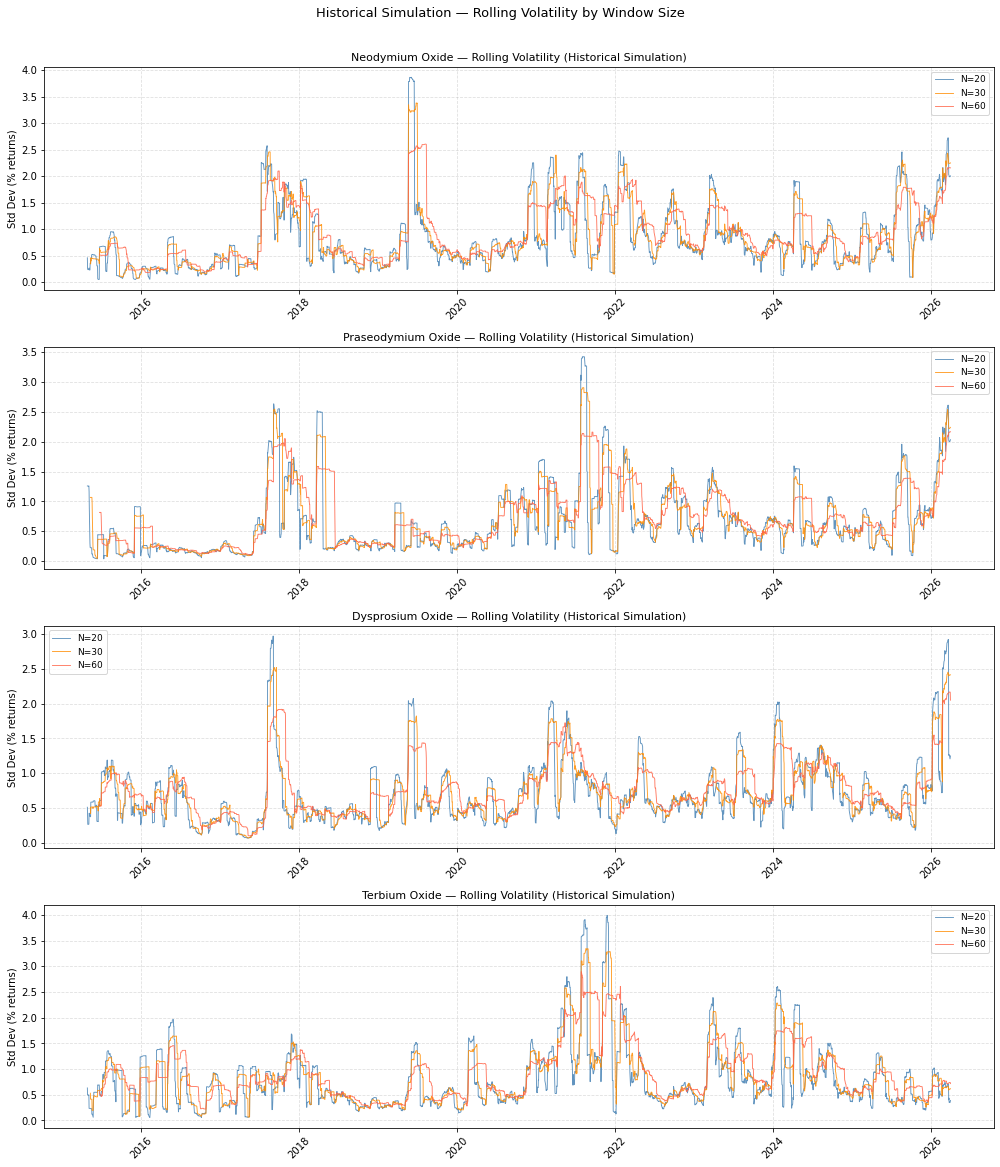

In [5]:
HS_WINDOWS = [20, 30, 60]
hs_results = {}

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
colors = ['steelblue', 'darkorange', 'tomato']

for i, (key, df) in enumerate(prepared.items()):
    label   = MINERALS[key]
    ret     = df['returns']
    hs_vars = {N: ret.rolling(N).var(ddof=0) for N in HS_WINDOWS}
    hs_results[key] = hs_vars

    ax = axes[i]
    for N, c in zip(HS_WINDOWS, colors):
        ax.plot(hs_vars[N].index, np.sqrt(hs_vars[N]),
                linewidth=0.9, alpha=0.85, color=c, label=f'N={N}')
    ax.set_title(f'{label} — Rolling Volatility (Historical Simulation)', fontsize=11)
    ax.set_ylabel('Std Dev (% returns)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Historical Simulation — Rolling Volatility by Window Size', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Model 2 — GARCH(1,1) Baseline

The standard GARCH(1,1) model (Bollerslev, 1986) serves as the parametric baseline with no sentiment information:

$$\sigma^2_t = \omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

We assume a zero-mean process and normally distributed innovations. Persistence is measured by $\alpha + \beta < 1$.

In [6]:
garch_results = {}

print('GARCH(1,1) estimation results')
print('=' * 65)

for key, df in prepared.items():
    label = MINERALS[key]
    ret   = df['returns']

    model = arch_model(ret, vol='Garch', p=1, q=1, mean='Zero', dist='normal')
    res   = model.fit(disp='off')
    garch_results[key] = res

    p = res.params
    print(f'\n{label}')
    print(f"  omega (w)  : {p['omega']:.6f}")
    print(f"  alpha (a)  : {p['alpha[1]']:.6f}")
    print(f"  beta  (b)  : {p['beta[1]']:.6f}")
    print(f"  a + b      : {p['alpha[1]'] + p['beta[1]']:.6f}  (persistence)")
    print(f"  Log-lik    : {res.loglikelihood:.4f}")
    print(f"  AIC        : {res.aic:.4f}")
    print(f"  BIC        : {res.bic:.4f}")

GARCH(1,1) estimation results

Neodymium Oxide
  omega (w)  : 0.008656
  alpha (a)  : 0.047888
  beta  (b)  : 0.952112
  a + b      : 1.000000  (persistence)
  Log-lik    : -4006.7891
  AIC        : 8019.5782
  BIC        : 8037.4644

Praseodymium Oxide
  omega (w)  : 0.003844
  alpha (a)  : 0.036778
  beta  (b)  : 0.963222
  a + b      : 1.000000  (persistence)
  Log-lik    : -3364.8553
  AIC        : 6735.7106
  BIC        : 6753.5968

Dysprosium Oxide
  omega (w)  : 0.019598
  alpha (a)  : 0.075593
  beta  (b)  : 0.908097
  a + b      : 0.983690  (persistence)
  Log-lik    : -3426.0398
  AIC        : 6858.0797
  BIC        : 6875.9659

Terbium Oxide
  omega (w)  : 0.011825
  alpha (a)  : 0.040022
  beta  (b)  : 0.952725
  a + b      : 0.992748  (persistence)
  Log-lik    : -3914.3957
  AIC        : 7834.7913
  BIC        : 7852.6775


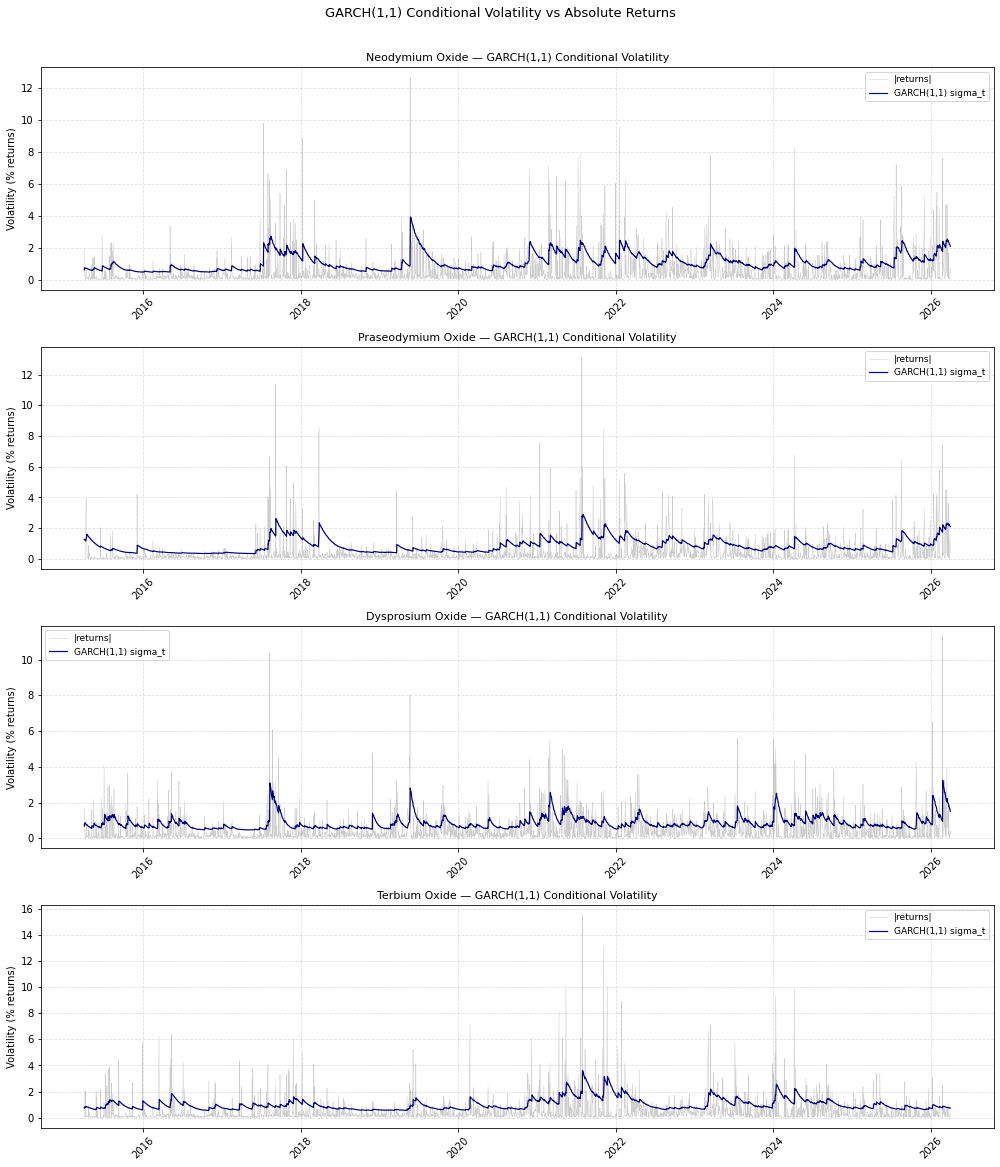

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for i, (key, df) in enumerate(prepared.items()):
    label    = MINERALS[key]
    res      = garch_results[key]
    cond_vol = res.conditional_volatility
    ret      = df['returns']

    ax = axes[i]
    ax.plot(ret.index, np.abs(ret), linewidth=0.5, color='grey', alpha=0.4, label='|returns|')
    ax.plot(cond_vol.index, cond_vol, linewidth=1.2, color='navy', label='GARCH(1,1) sigma_t')
    ax.set_title(f'{label} — GARCH(1,1) Conditional Volatility', fontsize=11)
    ax.set_ylabel('Volatility (% returns)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('GARCH(1,1) Conditional Volatility vs Absolute Returns', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Model 3 — EGARCH(1,1)-X  (Main Specification)

The Exponential GARCH with exogenous sentiment regressors (Nelson, 1991):

$$\ln(\sigma^2_t) = \omega + \alpha\left[|z_{t-1}| - \mathbb{E}|z_{t-1}|\right] + \xi z_{t-1} + \beta \ln(\sigma^2_{t-1}) + \gamma_1 \text{Tone}_{m,t-1} + \gamma_2 \text{Volume}_{m,t-1}$$

where $z_{t-1} = \varepsilon_{t-1}/\sigma_{t-1}$ and $\mathbb{E}|z| = \sqrt{2/\pi}$ for the standard normal. The log specification guarantees positivity without parameter constraints.

- $\xi < 0$: leverage effect (negative shocks raise volatility more than positive ones of equal magnitude).
- $\gamma_1, \gamma_2$: incremental effect of lagged (standardised) tone and log-news-volume on log variance.

Parameters estimated by MLE via `scipy.optimize` L-BFGS-B, initialised at the corresponding EGARCH(1,1) base estimates.

In [8]:
# Fit EGARCH(1,1) base models (no sentiment) for initialisation
egarch_base = {}
print('Fitting EGARCH(1,1) base models for initial parameters...')
for key, df in prepared.items():
    ret   = df['returns']
    model = arch_model(ret, vol='EGARCH', p=1, q=1, mean='Zero', dist='normal')
    res   = model.fit(disp='off')
    egarch_base[key] = res
    print(f'  {MINERALS[key]:25s}: LL={res.loglikelihood:.2f}  params={dict(res.params.round(4))}')

Fitting EGARCH(1,1) base models for initial parameters...
  Neodymium Oxide          : LL=-4083.99  params={'omega': 0.0463, 'alpha[1]': 0.138, 'beta[1]': 0.9835}
  Praseodymium Oxide       : LL=-3432.80  params={'omega': 0.0347, 'alpha[1]': 0.1028, 'beta[1]': 0.9932}
  Dysprosium Oxide         : LL=-3453.99  params={'omega': 0.0346, 'alpha[1]': 0.1758, 'beta[1]': 0.9676}
  Terbium Oxide            : LL=-3975.26  params={'omega': 0.0713, 'alpha[1]': 0.2312, 'beta[1]': 0.9304}


In [9]:
E_ABS_Z = np.sqrt(2.0 / np.pi)  # E[|z|] for standard normal


def egarch_x_negll(params, returns, tone_lag, volume_lag):
    """Negative log-likelihood for EGARCH(1,1)-X with normal innovations."""
    omega, alpha, xi, beta, gamma1, gamma2 = params
    n = len(returns)
    log_s2 = np.empty(n)
    log_s2[0] = np.log(max(np.var(returns), 1e-8))

    for t in range(1, n):
        sigma_prev = np.exp(np.clip(0.5 * log_s2[t - 1], -15, 15))
        z_prev     = returns[t - 1] / (sigma_prev + 1e-10)
        # tone_lag[t] = tone_mean[t-1] (already lagged in data prep)
        log_s2[t]  = (omega
                      + alpha * (abs(z_prev) - E_ABS_Z)
                      + xi    * z_prev
                      + beta  * log_s2[t - 1]
                      + gamma1 * tone_lag[t]
                      + gamma2 * volume_lag[t])
        if not np.isfinite(log_s2[t]):
            return 1e10

    sigma2 = np.exp(np.clip(log_s2, -30, 30))
    ll = -0.5 * np.sum(np.log(2 * np.pi * sigma2) + returns ** 2 / sigma2)
    return -ll if np.isfinite(ll) else 1e10


def compute_egarch_x_variance(params, returns, tone_lag, volume_lag):
    omega, alpha, xi, beta, gamma1, gamma2 = params
    n = len(returns)
    log_s2 = np.empty(n)
    log_s2[0] = np.log(max(np.var(returns), 1e-8))
    for t in range(1, n):
        sigma_prev = np.exp(np.clip(0.5 * log_s2[t - 1], -15, 15))
        z_prev     = returns[t - 1] / (sigma_prev + 1e-10)
        log_s2[t]  = (omega
                      + alpha * (abs(z_prev) - E_ABS_Z)
                      + xi    * z_prev
                      + beta  * log_s2[t - 1]
                      + gamma1 * tone_lag[t]
                      + gamma2 * volume_lag[t])
        log_s2[t] = np.clip(log_s2[t], -30, 30)
    return np.exp(log_s2)


egarch_x_results = {}

print('Estimating EGARCH(1,1)-X models...')
print('=' * 65)

for key, df in prepared.items():
    label  = MINERALS[key]
    ret    = df['returns'].values
    tone   = df['tone_lag'].values
    vol    = df['volume_lag'].values

    base = egarch_base[key].params
    p0   = [
        float(base['omega']),
        float(base['alpha[1]']),
        float(base.get('gamma[1]', 0.0)),  # xi (leverage)
        float(base['beta[1]']),
        0.0,  # gamma1 (tone)
        0.0,  # gamma2 (volume)
    ]

    opt = minimize(
        egarch_x_negll, p0, args=(ret, tone, vol),
        method='L-BFGS-B',
        options={'maxiter': 3000, 'ftol': 1e-11},
    )
    ll = -opt.fun
    k  = len(opt.x)
    n  = len(ret)
    egarch_x_results[key] = {'params': opt.x, 'loglik': ll, 'success': opt.success}

    omega, alpha, xi, beta, g1, g2 = opt.x
    print(f'\n{label}')
    print(f'  omega (w)    : {omega:.6f}')
    print(f'  alpha (a)    : {alpha:.6f}')
    print(f'  xi           : {xi:.6f}  <- leverage (< 0 = bad-news amplification)')
    print(f'  beta  (b)    : {beta:.6f}')
    print(f'  gamma1 (tone): {g1:.6f}')
    print(f'  gamma2 (vol) : {g2:.6f}')
    print(f'  Log-lik      : {ll:.4f}')
    print(f'  AIC          : {2*k - 2*ll:.4f}')
    print(f'  BIC          : {k*np.log(n) - 2*ll:.4f}')
    print(f'  Converged    : {opt.success}')

Estimating EGARCH(1,1)-X models...

Neodymium Oxide
  omega (w)    : 0.047273
  alpha (a)    : 0.146650
  xi           : 0.024444  <- leverage (< 0 = bad-news amplification)
  beta  (b)    : 0.981416
  gamma1 (tone): 0.027525
  gamma2 (vol) : 0.003021
  Log-lik      : -4046.0226
  AIC          : 8104.0452
  BIC          : 8139.8176
  Converged    : True

Praseodymium Oxide
  omega (w)    : 0.018864
  alpha (a)    : 0.057398
  xi           : 0.032871  <- leverage (< 0 = bad-news amplification)
  beta  (b)    : 0.996807
  gamma1 (tone): 0.003222
  gamma2 (vol) : -0.001365
  Log-lik      : -3347.2531
  AIC          : 6706.5062
  BIC          : 6742.2786
  Converged    : True

Dysprosium Oxide
  omega (w)    : 0.022668
  alpha (a)    : 0.256636
  xi           : 0.036925  <- leverage (< 0 = bad-news amplification)
  beta  (b)    : 0.904416
  gamma1 (tone): 0.055921
  gamma2 (vol) : 0.057150
  Log-lik      : -3387.2366
  AIC          : 6786.4731
  BIC          : 6822.2455
  Converged    : Tr

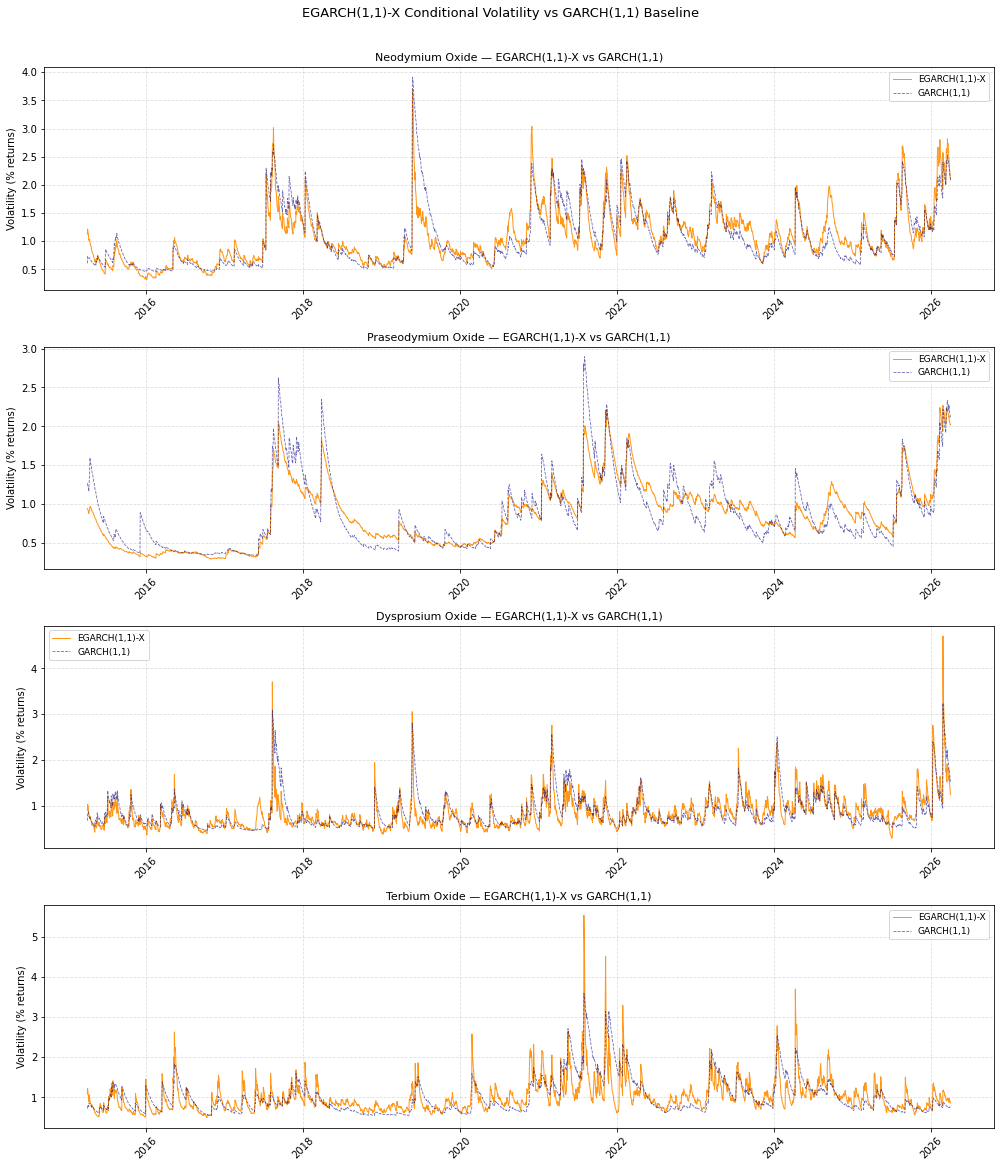

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for i, (key, df) in enumerate(prepared.items()):
    label = MINERALS[key]
    ret   = df['returns'].values
    tone  = df['tone_lag'].values
    vol   = df['volume_lag'].values
    dates = df.index

    s2_ex = compute_egarch_x_variance(egarch_x_results[key]['params'], ret, tone, vol)
    s_g   = garch_results[key].conditional_volatility

    ax = axes[i]
    ax.plot(dates,    np.sqrt(s2_ex), lw=1.0, color='darkorange', label='EGARCH(1,1)-X', alpha=0.9)
    ax.plot(s_g.index, s_g,           lw=0.8, color='navy',       label='GARCH(1,1)',    alpha=0.6, linestyle='--')
    ax.set_title(f'{label} — EGARCH(1,1)-X vs GARCH(1,1)', fontsize=11)
    ax.set_ylabel('Volatility (% returns)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('EGARCH(1,1)-X Conditional Volatility vs GARCH(1,1) Baseline', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Model 4 — GJR-GARCH(1,1)-X  (Asymmetry Test)

The Glosten-Jagannathan-Runkle GARCH with exogenous sentiment regressors (Glosten et al., 1993):

$$\sigma^2_t = \omega + \alpha \varepsilon^2_{t-1} + \xi \varepsilon^2_{t-1} \cdot \mathbb{1}[\varepsilon_{t-1} < 0] + \beta \sigma^2_{t-1} + \delta_1 \text{Polarity}_{m,t-1} + \delta_2 \text{NegTone}_{m,t-1}$$

- $\xi > 0$: negative return shocks amplify variance more than positive ones (leverage effect).
- $\delta_1, \delta_2$: incremental effect of lagged (standardised) total emotional intensity and negative media coverage.

Positivity is enforced via L-BFGS-B bounds: $\omega > 0$, $\alpha \geq 0$, $\beta \geq 0$. Initialised at the corresponding GJR-GARCH(1,1) estimates.

In [11]:
# Fit GJR-GARCH(1,1) base models for initialisation
gjr_base = {}
print('Fitting GJR-GARCH(1,1) base models for initial parameters...')
for key, df in prepared.items():
    ret   = df['returns']
    model = arch_model(ret, vol='GARCH', p=1, o=1, q=1, mean='Zero', dist='normal')
    res   = model.fit(disp='off')
    gjr_base[key] = res
    print(f'  {MINERALS[key]:25s}: LL={res.loglikelihood:.2f}  params={dict(res.params.round(4))}')

Fitting GJR-GARCH(1,1) base models for initial parameters...
  Neodymium Oxide          : LL=-4006.74  params={'omega': 0.0087, 'alpha[1]': 0.0472, 'gamma[1]': 0.0013, 'beta[1]': 0.9521}
  Praseodymium Oxide       : LL=-3359.96  params={'omega': 0.0037, 'alpha[1]': 0.0415, 'gamma[1]': -0.011, 'beta[1]': 0.964}
  Dysprosium Oxide         : LL=-3421.86  params={'omega': 0.0215, 'alpha[1]': 0.0901, 'gamma[1]': -0.0253, 'beta[1]': 0.9035}
  Terbium Oxide            : LL=-3913.36  params={'omega': 0.0108, 'alpha[1]': 0.0346, 'gamma[1]': 0.0063, 'beta[1]': 0.9558}


In [12]:
def gjr_garch_x_negll(params, returns, polarity_lag, neg_tone_lag):
    """Negative log-likelihood for GJR-GARCH(1,1)-X with normal innovations."""
    omega, alpha, xi, beta, delta1, delta2 = params
    n = len(returns)
    s2 = np.empty(n)
    s2[0] = max(np.var(returns), 1e-8)

    for t in range(1, n):
        eps   = returns[t - 1]
        I_neg = 1.0 if eps < 0 else 0.0
        # polarity_lag[t] = polarity_mean[t-1] (already lagged in data prep)
        s2[t] = (omega
                 + alpha  * eps ** 2
                 + xi     * eps ** 2 * I_neg
                 + beta   * s2[t - 1]
                 + delta1 * polarity_lag[t]
                 + delta2 * neg_tone_lag[t])
        if s2[t] <= 0 or not np.isfinite(s2[t]):
            return 1e10

    ll = -0.5 * np.sum(np.log(2 * np.pi * s2) + returns ** 2 / s2)
    return -ll if np.isfinite(ll) else 1e10


def compute_gjr_x_variance(params, returns, polarity_lag, neg_tone_lag):
    omega, alpha, xi, beta, delta1, delta2 = params
    n = len(returns)
    s2 = np.empty(n)
    s2[0] = max(np.var(returns), 1e-8)
    for t in range(1, n):
        eps   = returns[t - 1]
        I_neg = 1.0 if eps < 0 else 0.0
        s2[t] = (omega
                 + alpha  * eps ** 2
                 + xi     * eps ** 2 * I_neg
                 + beta   * s2[t - 1]
                 + delta1 * polarity_lag[t]
                 + delta2 * neg_tone_lag[t])
        s2[t] = max(s2[t], 1e-8)
    return s2


gjr_x_results = {}

print('Estimating GJR-GARCH(1,1)-X models...')
print('=' * 65)

for key, df in prepared.items():
    label    = MINERALS[key]
    ret      = df['returns'].values
    polarity = df['polarity_lag'].values
    neg_tone = df['neg_tone_lag'].values

    base = gjr_base[key].params
    p0   = [
        float(base['omega']),
        float(base['alpha[1]']),
        float(base.get('gamma[1]', 0.0)),  # xi (asymmetry)
        float(base['beta[1]']),
        0.0,  # delta1 (polarity)
        0.0,  # delta2 (neg_tone)
    ]
    bounds = [
        (1e-8, None),   # omega > 0
        (0.0,  None),   # alpha >= 0
        (None, None),   # xi (can be negative)
        (0.0,  0.9999), # 0 <= beta < 1
        (None, None),   # delta1
        (None, None),   # delta2
    ]

    opt = minimize(
        gjr_garch_x_negll, p0, args=(ret, polarity, neg_tone),
        method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 3000, 'ftol': 1e-11},
    )
    ll = -opt.fun
    k  = len(opt.x)
    n  = len(ret)
    gjr_x_results[key] = {'params': opt.x, 'loglik': ll, 'success': opt.success}

    omega, alpha, xi, beta, d1, d2 = opt.x
    print(f'\n{label}')
    print(f'  omega (w)       : {omega:.6f}')
    print(f'  alpha (a)       : {alpha:.6f}')
    print(f'  xi              : {xi:.6f}  <- asymmetry (> 0 = leverage effect)')
    print(f'  beta  (b)       : {beta:.6f}')
    print(f'  delta1 (polarity): {d1:.6f}')
    print(f'  delta2 (neg_tone): {d2:.6f}')
    print(f'  Log-lik         : {ll:.4f}')
    print(f'  AIC             : {2*k - 2*ll:.4f}')
    print(f'  BIC             : {k*np.log(n) - 2*ll:.4f}')
    print(f'  Converged       : {opt.success}')

Estimating GJR-GARCH(1,1)-X models...

Neodymium Oxide
  omega (w)       : 0.013599
  alpha (a)       : 0.042771
  xi              : -0.002091  <- asymmetry (> 0 = leverage effect)
  beta  (b)       : 0.952510
  delta1 (polarity): 0.031911
  delta2 (neg_tone): -0.020380
  Log-lik         : -3942.4242
  AIC             : 7896.8484
  BIC             : 7932.6208
  Converged       : True

Praseodymium Oxide
  omega (w)       : 0.003700
  alpha (a)       : 0.041466
  xi              : -0.010953  <- asymmetry (> 0 = leverage effect)
  beta  (b)       : 0.964011
  delta1 (polarity): 0.000000
  delta2 (neg_tone): 0.000000
  Log-lik         : -3356.6615
  AIC             : 6725.3230
  BIC             : 6761.0954
  Converged       : False

Dysprosium Oxide
  omega (w)       : 0.067748
  alpha (a)       : 0.135067
  xi              : -0.036055  <- asymmetry (> 0 = leverage effect)
  beta  (b)       : 0.805169
  delta1 (polarity): 0.085372
  delta2 (neg_tone): -0.057612
  Log-lik         : -3372.3

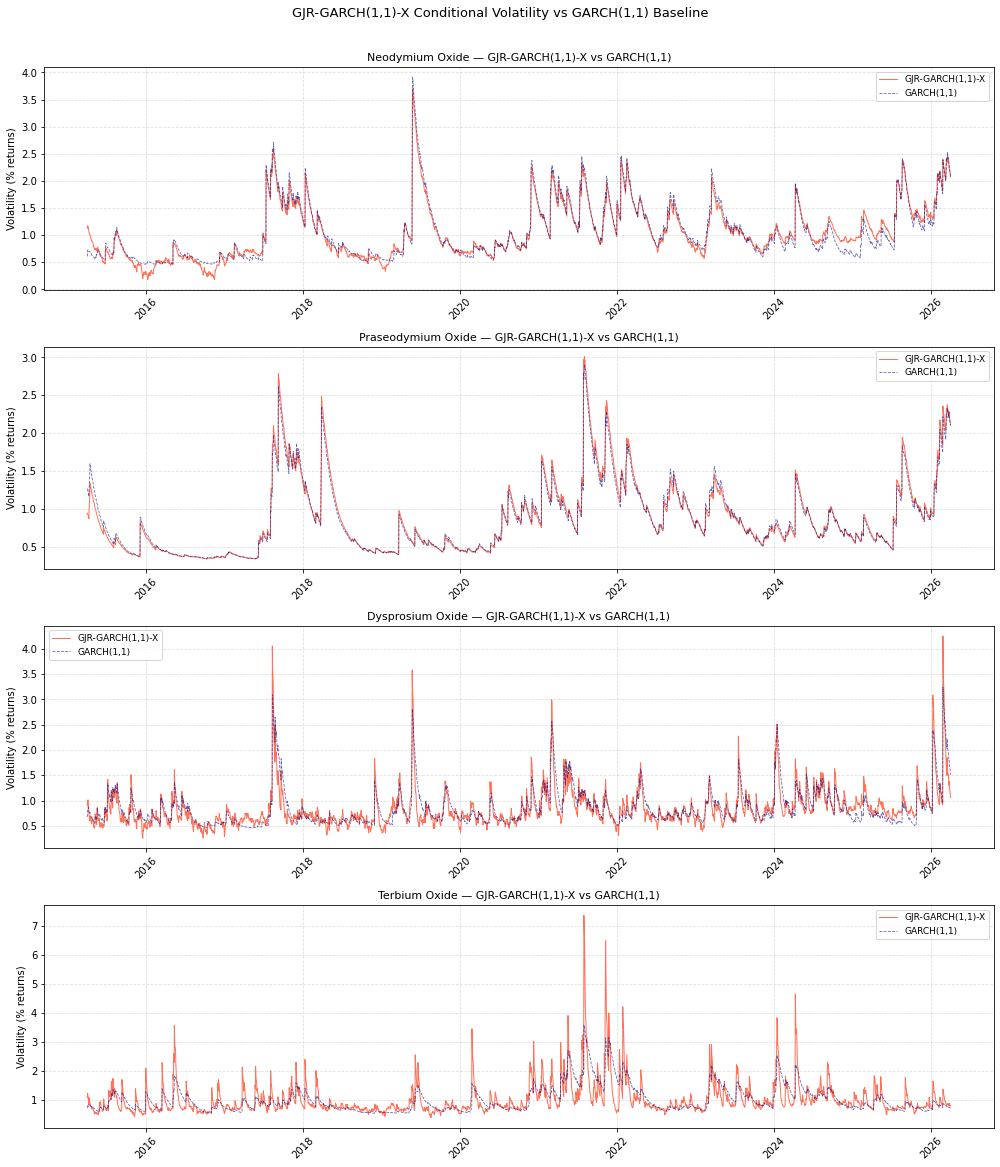

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for i, (key, df) in enumerate(prepared.items()):
    label    = MINERALS[key]
    ret      = df['returns'].values
    polarity = df['polarity_lag'].values
    neg_tone = df['neg_tone_lag'].values
    dates    = df.index

    s2_gx = compute_gjr_x_variance(gjr_x_results[key]['params'], ret, polarity, neg_tone)
    s_g   = garch_results[key].conditional_volatility

    ax = axes[i]
    ax.plot(dates,     np.sqrt(s2_gx), lw=1.0, color='tomato', label='GJR-GARCH(1,1)-X', alpha=0.9)
    ax.plot(s_g.index, s_g,            lw=0.8, color='navy',   label='GARCH(1,1)',        alpha=0.6, linestyle='--')
    ax.set_title(f'{label} — GJR-GARCH(1,1)-X vs GARCH(1,1)', fontsize=11)
    ax.set_ylabel('Volatility (% returns)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('GJR-GARCH(1,1)-X Conditional Volatility vs GARCH(1,1) Baseline', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Results Comparison

We compile a summary table comparing log-likelihood, AIC, and BIC across the three parametric models for each mineral. Lower AIC/BIC indicates a better fit after penalising for model complexity.

In [14]:
rows = []
for key in MINERALS:
    label = MINERALS[key]
    n_obs = len(prepared[key])

    # GARCH(1,1)
    g  = garch_results[key]
    rows.append({'Mineral': label, 'Model': 'GARCH(1,1)',
                 'k': 3, 'Log-lik': round(g.loglikelihood, 2),
                 'AIC': round(g.aic, 2), 'BIC': round(g.bic, 2)})

    # EGARCH(1,1)-X
    ex = egarch_x_results[key]
    k, ll = 6, ex['loglik']
    rows.append({'Mineral': label, 'Model': 'EGARCH(1,1)-X',
                 'k': k, 'Log-lik': round(ll, 2),
                 'AIC': round(2*k - 2*ll, 2), 'BIC': round(k*np.log(n_obs) - 2*ll, 2)})

    # GJR-GARCH(1,1)-X
    gx = gjr_x_results[key]
    k, ll = 6, gx['loglik']
    rows.append({'Mineral': label, 'Model': 'GJR-GARCH(1,1)-X',
                 'k': k, 'Log-lik': round(ll, 2),
                 'AIC': round(2*k - 2*ll, 2), 'BIC': round(k*np.log(n_obs) - 2*ll, 2)})

summary = pd.DataFrame(rows).set_index(['Mineral', 'Model'])
print('Model Comparison Summary')
print('=' * 65)
print(summary.to_string())

Model Comparison Summary
                                     k      Log-lik         AIC         BIC
Mineral            Model                                                   
Neodymium Oxide    GARCH(1,1)        3 -4006.790000 8019.580000 8037.460000
                   EGARCH(1,1)-X     6 -4046.020000 8104.050000 8139.820000
                   GJR-GARCH(1,1)-X  6 -3942.420000 7896.850000 7932.620000
Praseodymium Oxide GARCH(1,1)        3 -3364.860000 6735.710000 6753.600000
                   EGARCH(1,1)-X     6 -3347.250000 6706.510000 6742.280000
                   GJR-GARCH(1,1)-X  6 -3356.660000 6725.320000 6761.100000
Dysprosium Oxide   GARCH(1,1)        3 -3426.040000 6858.080000 6875.970000
                   EGARCH(1,1)-X     6 -3387.240000 6786.470000 6822.250000
                   GJR-GARCH(1,1)-X  6 -3372.360000 6756.720000 6792.490000
Terbium Oxide      GARCH(1,1)        3 -3914.400000 7834.790000 7852.680000
                   EGARCH(1,1)-X     6 -3949.230000 7910.460000